<a href="https://colab.research.google.com/github/AkshayGovindaraj/Computational-Statistics/blob/master/pyf_project_learner_notebook_full_codev2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Python Foundations: FoodHub Data Analysis

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost_of_the_order: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [1]:
# Installing the libraries with the specified version.
!pip install numpy==2.0.2 pandas==2.2.2 matplotlib==3.10.0 seaborn==0.13.2 -q --user

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [2]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [3]:
# uncomment and run the below code snippets if the dataset is present in the Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

In [4]:
# Write your code here to read the data
df = pd.read_csv('foodhub_order.csv')

In [5]:
# Write your code here to view the first 5 rows
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [6]:
# Write your code here
df.shape

(1898, 9)

#### Observations:
There are 1898 rows and 9 columns in ther dataset

### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [7]:
# Write your code here
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:
1) The following fileds are integers and are fairly so: order_id, customer_id, food_preparation_time, delivery_time.
2) day_of_the_week is an object (string) and it would be better to convert that to datetime format.
3) rating is an object (string) but it should be an integer. Perhaps some orders are not rated and therefore it is a string.
4) restaurant_name and cuisine_type are objects (strings) and should remain so. They could be treated as categorical variables.


### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [8]:
# Write your code here
df.isna().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,0
food_preparation_time,0
delivery_time,0


In [9]:
df.isnull().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,0
food_preparation_time,0
delivery_time,0


In [10]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,1898.0,NaN,NaN,NaN,1477495.5,548.049724,1476547.0,1477021.25,1477495.5,1477969.75,1478444.0
customer_id,1898.0,NaN,NaN,NaN,171168.478398,113698.139743,1311.0,77787.75,128600.0,270525.0,405334.0
restaurant_name,1898,178,Shake Shack,219,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cuisine_type,1898,14,American,584,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cost_of_the_order,1898.0,NaN,NaN,NaN,16.498851,7.483812,4.47,12.08,14.14,22.2975,35.41
day_of_the_week,1898,2,Weekend,1351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,1898,4,Not given,736,NaN,NaN,NaN,NaN,NaN,NaN,NaN
food_preparation_time,1898.0,NaN,NaN,NaN,27.37197,4.632481,20.0,23.0,27.0,31.0,35.0
delivery_time,1898.0,NaN,NaN,NaN,24.161749,4.972637,15.0,20.0,25.0,28.0,33.0


In [11]:
df.groupby(['rating'])['rating'].count().loc['3']

np.int64(188)

#### Observations:
There are no fields in any of the row which are null or NaN in this dataset. So it seems all numeric variables have the data. Some orders were not rated and therefore the ratings field has 'Not Missing' as value in some of the rows.

There are ratings which are 'Not given'. THose should perhaps we replaced by the mean ratings.

In [12]:
mean = pd.to_numeric(df['rating'], errors='coerce').mean()
mean

np.float64(4.344234079173838)

The above code calculates the mean of all ratings given. THat turns out to be 4.34. So we will replace all 'Not given' with 4.34

In [13]:
df['rating_adjusted'] = pd.to_numeric(df['rating'].replace(['Not given'], 4.34))

In [14]:
df.groupby(['rating_adjusted'])['rating_adjusted'].count()

,rating_adjusted
rating_adjusted,
3.00,188
4.00,386
4.34,736
5.00,588


This make it possible to calculate correlations or understand any kind of relation with other factors.

### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [15]:
# Write your code here
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,1898.0,NaN,NaN,NaN,1477495.5,548.049724,1476547.0,1477021.25,1477495.5,1477969.75,1478444.0
customer_id,1898.0,NaN,NaN,NaN,171168.478398,113698.139743,1311.0,77787.75,128600.0,270525.0,405334.0
restaurant_name,1898,178,Shake Shack,219,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cuisine_type,1898,14,American,584,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cost_of_the_order,1898.0,NaN,NaN,NaN,16.498851,7.483812,4.47,12.08,14.14,22.2975,35.41
day_of_the_week,1898,2,Weekend,1351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,1898,4,Not given,736,NaN,NaN,NaN,NaN,NaN,NaN,NaN
food_preparation_time,1898.0,NaN,NaN,NaN,27.37197,4.632481,20.0,23.0,27.0,31.0,35.0
delivery_time,1898.0,NaN,NaN,NaN,24.161749,4.972637,15.0,20.0,25.0,28.0,33.0
rating_adjusted,1898.0,NaN,NaN,NaN,4.342592,0.580074,3.0,4.0,4.34,5.0,5.0


#### Observations:
Food Preparation Time:
1) Minimum: 20 minutes
2) Average: 27.37 minutes
3) Maximum: 35 minutes


### **Question 5:** How many orders are not rated? [1 mark]

In [16]:
# Write the code here
df['rating'].value_counts()

,count
rating,
Not given,736
5,588
4,386
3,188


#### Observations:

There were a total of 736  orders out of 1898 which were not rated.

### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

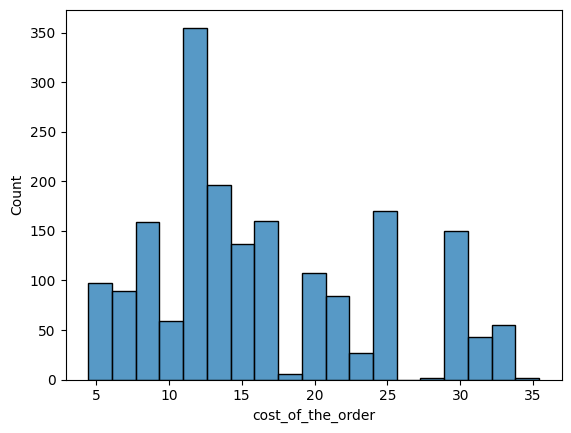

In [17]:
# Write the code here
sns.histplot(data=df['cost_of_the_order']);

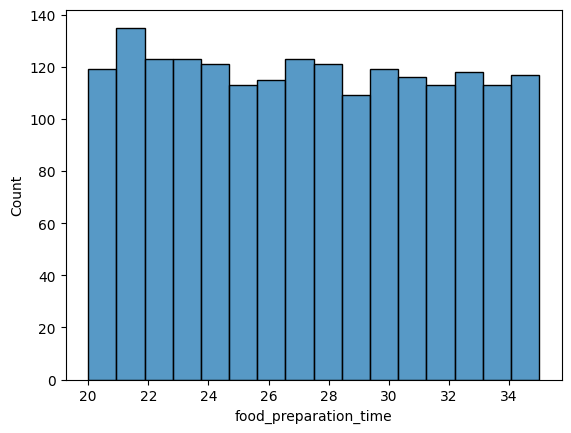

In [18]:
sns.histplot(data=df['food_preparation_time'], bins=16);

<Axes: xlabel='delivery_time', ylabel='Count'>

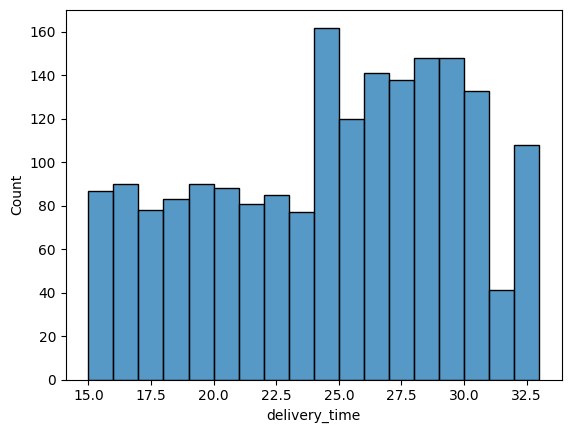

In [19]:
sns.histplot(data=df['delivery_time'], binwidth=1)

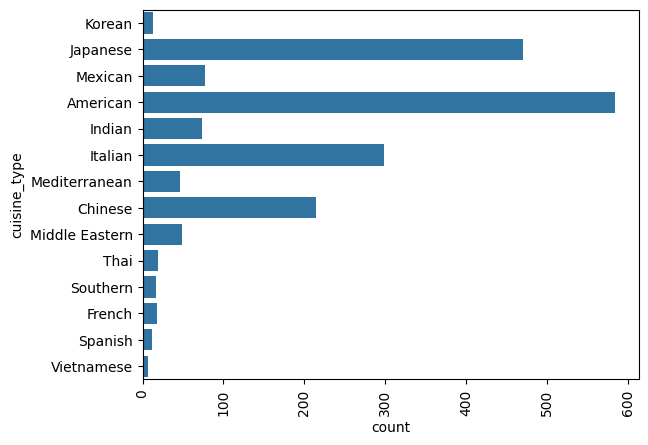

In [20]:
sns.countplot(data=df['cuisine_type'])
plt.xticks(rotation=90)
plt.show()
#

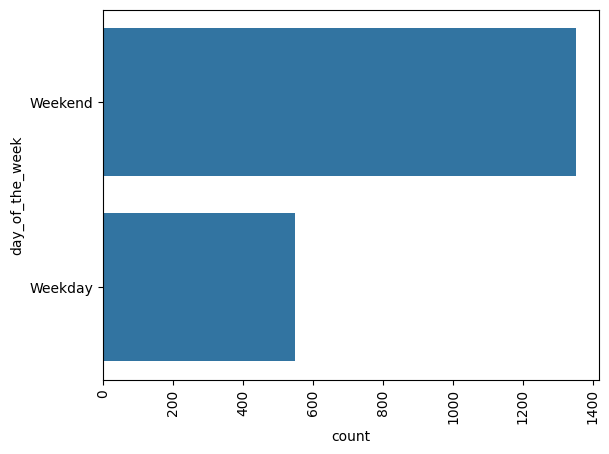

In [21]:
sns.countplot(data=df['day_of_the_week'])
plt.xticks(rotation=90)
plt.show()
#

In [22]:
df['restaurant_name'].value_counts()


,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68
...,...
Rye House,1
Hiroko's Place,1
Frank Restaurant,1


<Axes: xlabel='count', ylabel='rating'>

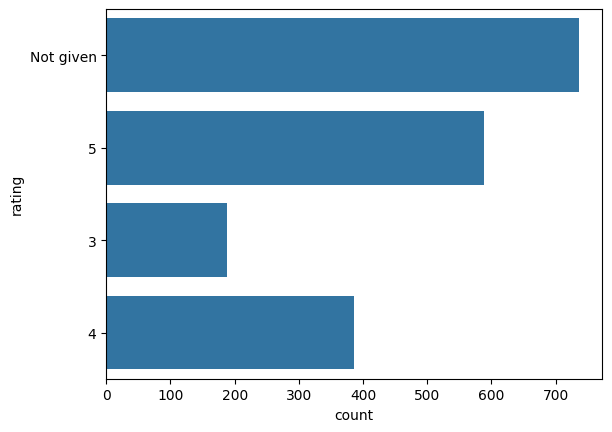

In [23]:
sns.countplot(data=df['rating'])

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [24]:
# Write the code here
df[['restaurant_name']].value_counts().head()

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68


#### Observations:
The top 5 restaurants are:
1) Shake Shack
2) The Meatball Shop
3) Blue Ribbon Sushi
4) Blue Ribbon Fried Chicken
5) Parm

Pandas value_counts() function will order them in desending order and therefore it can be used for this purpose.

### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [25]:
# Write the code here
df[df['day_of_the_week']=='Weekend']['cuisine_type'].value_counts().head()

,count
cuisine_type,
American,415
Japanese,335
Italian,207
Chinese,163
Mexican,53


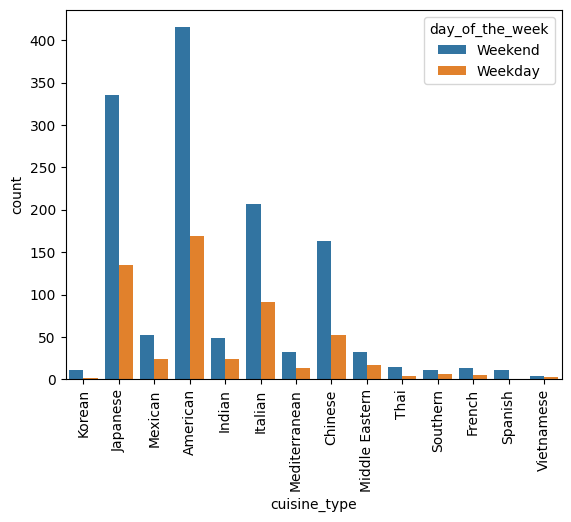

In [26]:
sns.countplot(data=df, x='cuisine_type', hue='day_of_the_week')
plt.xticks(rotation=90)
plt.show()

#### Observations:
The most popular cuisine in weekends is American which is closely followed by Japanese. The distribution is fairly similar for weekdays and weekends.

### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [27]:
# Write the code here
df[df['cost_of_the_order']>20].value_counts().sum()/df.shape[0]*100

np.float64(29.24130663856691)

#### Observations:
29.24% of the orders have a cost of more than $20.


### **Question 10**: What is the mean order delivery time? [1 mark]

In [28]:
# Write the code here
df['delivery_time'].mean()


np.float64(24.161749209694417)

#### Observations:
The mean delivery time is 24.16 minutes.

One observation is that this is higher than the mean preparation time (27 minutes). Therefore, the delivery time is perhaps only the time after preparation to delivery. The total order time would be the sum of preparation time and the delivery time.


### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [29]:
# Write the code here
df['customer_id'].value_counts().head(3)

,count
customer_id,
52832,13
47440,10
83287,9


#### Observations:

The top 3 most frequent customers are:

1) 52832 (customer_id) - 13 orders
2) 47440 - 10 orders
3) 83287 - 9 orders


### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


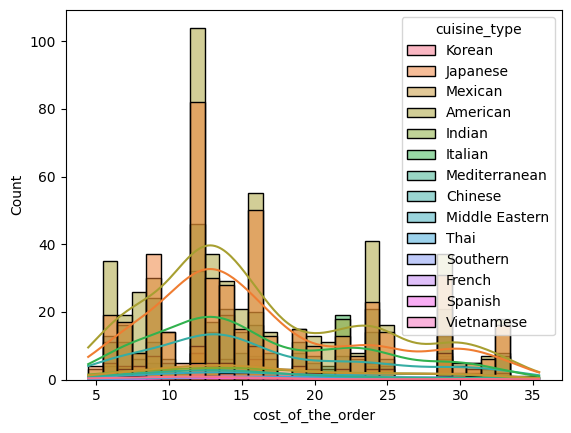

In [30]:
# Write the code here
sns.histplot(data=df, x='cost_of_the_order', hue='cuisine_type', binwidth =1, kde='True');

Observation: Based on the kde lines we don't see any trend. All cuisines have a wide price range. In other words, the price doesn't depend on the cuisine.

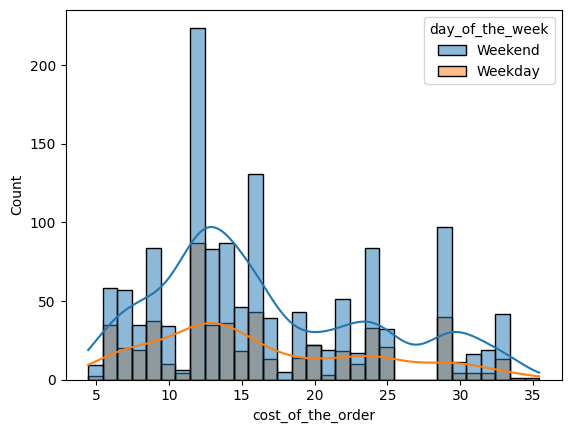

In [31]:
sns.histplot(data=df, x='cost_of_the_order', hue='day_of_the_week', binwidth =1, kde='True');

Observation: We may have expected the order cost to be higher during weeekends but it is somewhat similar to Weekdays based on the above chart.

<Axes: >

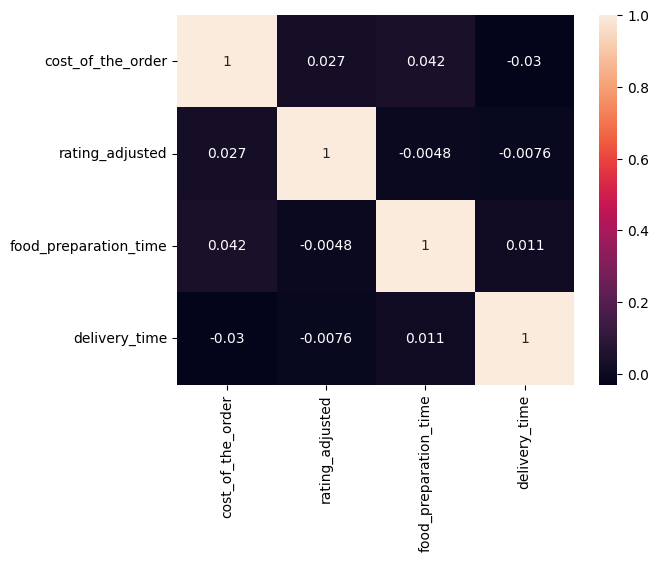

In [32]:
sns.heatmap(data=df[['cost_of_the_order', 'rating_adjusted', 'food_preparation_time', 'delivery_time']].corr(), annot=True)

Observation: Based on the correlation plot we don't see a stronger correlation between any two pairs of numeric variables. THis needs to be confirmed with scatterplots.

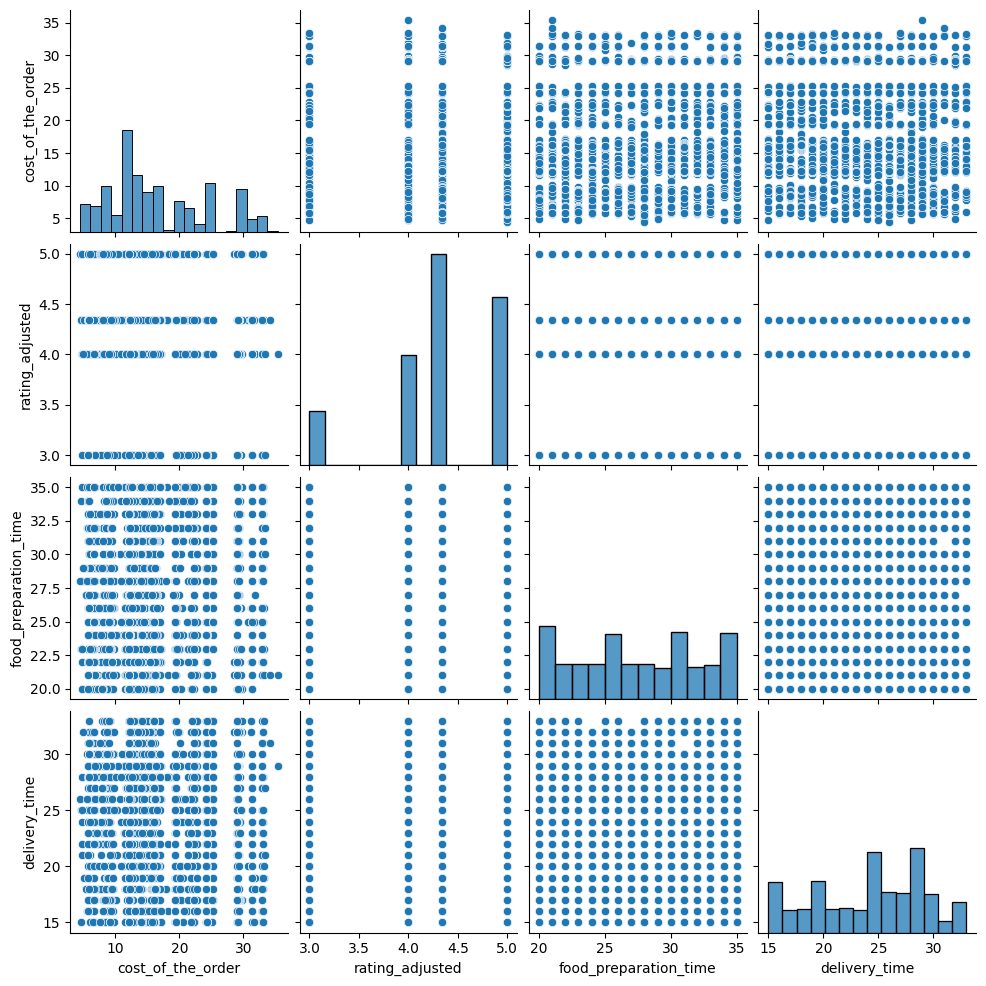

In [33]:
sns.pairplot(data=df[['cost_of_the_order', 'rating_adjusted', 'food_preparation_time', 'delivery_time']])

Confirmed that there isn't a strong correlation betweeen the numeric variables. Perhaps there are dependecies between categorical variables.

In [34]:
df

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time,rating_adjusted
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20,4.34
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23,4.34
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28,5.00
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15,3.00
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24,4.00
...,...,...,...,...,...,...,...,...,...,...
1893,1476701,292602,Chipotle Mexican Grill $1.99 Delivery,Mexican,22.31,Weekend,5,31,17,5.00
1894,1477421,397537,The Smile,American,12.18,Weekend,5,31,19,5.00
1895,1477819,35309,Blue Ribbon Sushi,Japanese,25.22,Weekday,Not given,31,24,4.34
1896,1477513,64151,Jack's Wife Freda,Mediterranean,12.18,Weekday,5,23,31,5.00


### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [35]:
# Write the code here
restaurant_df1 = df.groupby('restaurant_name', as_index=False).agg({
    'rating_adjusted': 'mean',
    'order_id': 'count'
})
restaurant_df1

,restaurant_name,rating_adjusted,order_id
0,'wichcraft,5.000000,1
1,12 Chairs,4.420000,4
2,5 Napkin Burger,4.204000,5
3,67 Burger,5.000000,1
4,Alidoro,4.340000,1
...,...,...,...
173,Zero Otto Nove,4.170000,2
174,brgr,3.670000,2
175,da Umberto,4.560000,3
176,ilili Restaurant,4.205556,18


In [36]:
restaurant_df1.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
restaurant_name,178,178,'wichcraft,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating_adjusted,178.0,NaN,NaN,NaN,4.374608,0.416477,3.0,4.201405,4.34,4.636964,5.0
order_id,178.0,NaN,NaN,NaN,10.662921,24.047008,1.0,1.0,3.0,8.75,219.0


In [38]:
restaurant_df1.loc[(restaurant_df1['rating_adjusted']>4) & (restaurant_df1['order_id']>50)]

,restaurant_name,rating_adjusted,order_id
20,Blue Ribbon Fried Chicken,4.332083,96
21,Blue Ribbon Sushi,4.265882,119
109,Parm,4.218529,68
121,RedFarm Broadway,4.273220,59
122,RedFarm Hudson,4.238909,55
136,Shake Shack,4.302466,219
153,The Meatball Shop,4.449394,132


#### Observations:
The following restaurants meet the

### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [39]:
# Write the code here
def restaurant_charge(order_cost):
  if(order_cost>20): return (0.25*order_cost)
  elif(order_cost>5): return (0.15*order_cost)
  else: return 0

In [40]:
company_revenue = 0
for order_cost in df['cost_of_the_order']: company_revenue+= restaurant_charge(order_cost)

In [41]:
company_revenue

6166.302999999994

#### Observations:
For the given list of orders, the total revenue for the company is $6,166.30


### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [43]:
# Write the code here
df['total_time'] = df['food_preparation_time'] + df['delivery_time']

<Axes: xlabel='total_time', ylabel='Count'>

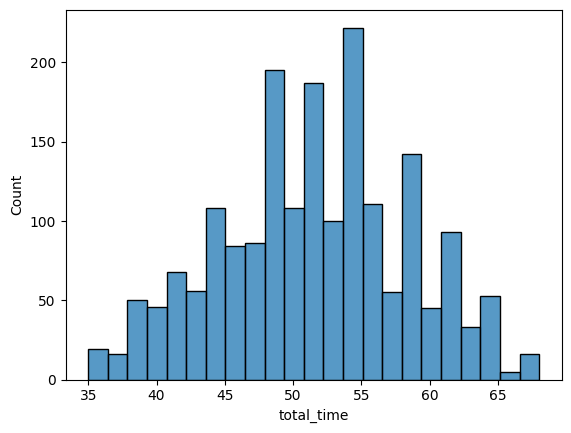

In [44]:
sns.histplot(data=df, x='total_time')

In [48]:
df.loc[df['total_time']>60]['total_time'].count()/df['total_time'].count()

np.float64(0.1053740779768177)

In [49]:
df.loc[df['total_time']>60]['total_time'].count()

np.int64(200)

#### Observations:
200 orders or about 10.5% of the orders take a total time more than 60 minutes. That looks about right looking at the chart.

### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [58]:
# Write the code here
df.loc[df['day_of_the_week'] == 'Weekend']['delivery_time'].mean()

np.float64(22.4700222057735)

In [59]:
df.loc[df['day_of_the_week'] == 'Weekday']['delivery_time'].mean()

np.float64(28.340036563071298)

#### Observations:
The mean delivery time in Weekdays is more than Weekends.
Weekdays - 28.34 minutes
Weekends - 22.47 minutes


<Axes: xlabel='delivery_time', ylabel='Count'>

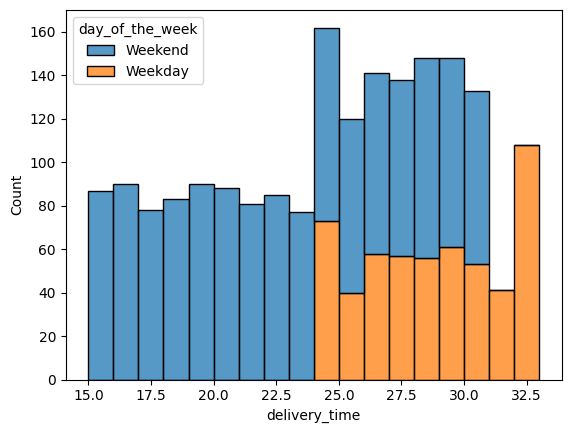

In [62]:
sns.histplot(data=df,x='delivery_time',hue='day_of_the_week', multiple= 'stack', binwidth = 1)

### Conclusion and Recommendations
From the stacked histogram it looks like on Weekdays the order takes a minimum of 24 minutes. This might be due to additional traffic during weekdays or there might be an efficiency related to lack of delivery personnel.

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:
*  

### Recommendations:

*  

---